In [ ]:
# 1. Importación de Librerías y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import json

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Carga de Datos
import os
import json
import pandas as pd

DATA_PATH = '../data/miner_dataset.json'

if os.path.exists(DATA_PATH):
    try:
        # Cargar el JSON generado por el Miner
        with open(DATA_PATH, 'r') as file:
            raw_data = json.load(file)
        
        if "vulnerabilities" in raw_data:
            df = pd.DataFrame(raw_data["vulnerabilities"])
        else:
            df = pd.DataFrame(raw_data) # Por si la estructura es plana
            
        print(f"Datos cargados exitosamente. Total de vulnerabilidades: {len(df)}")
        
        # Visualizar las primeras filas solo si se cargó correctamente
        display(df.head())
        
    except Exception as e:
        print(f"Ocurrió un error al cargar los datos: {e}")
else:
    print(f"Error: No se encontró el archivo en {DATA_PATH}.")


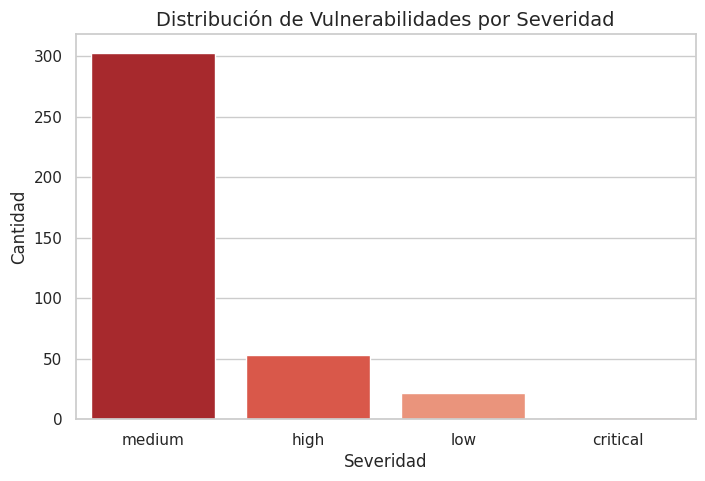

In [13]:
# 4. Análisis Exploratorio: Severidad
if 'severity' in df.columns:
    severity_counts = df['severity'].value_counts()
    
    # Gráfico de barras con Seaborn
    plt.figure(figsize=(8, 5))
    sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='Reds_r',  hue=severity_counts.index, legend=False)
    plt.title('Distribución de Vulnerabilidades por Severidad', fontsize=14)
    plt.xlabel('Severidad')
    plt.ylabel('Cantidad')
    plt.show()
else:
    print("La columna 'severity' no existe en el dataset. Verifica los nombres de las columnas.")

In [6]:
# Preparación de DataFrames por Herramienta

COL_TOOL = 'source_tool' 
COL_REPO = 'repository'
COL_VULN_NAME = 'vulnerability_id'
COL_SEVERITY = 'severity'

# Separar los datos
df_grype = df[df[COL_TOOL].str.lower() == 'grype'].copy()
df_codeql = df[df[COL_TOOL].str.lower() == 'codeql'].copy()

print(f"Total vulnerabilidades Grype: {len(df_grype)}")
print(f"Total vulnerabilidades CodeQL: {len(df_codeql)}")

Total vulnerabilidades Grype: 162
Total vulnerabilidades CodeQL: 218


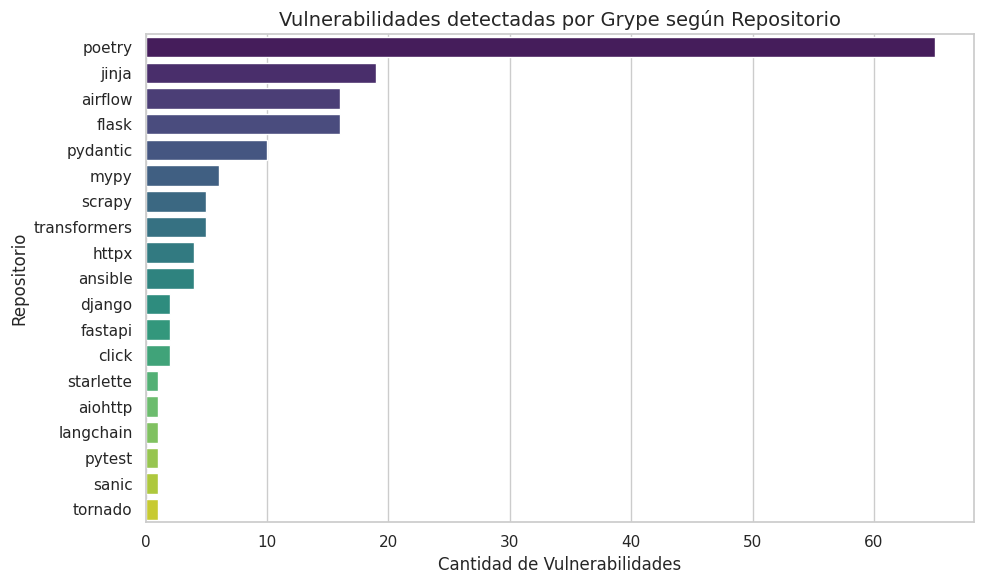

El repositorio con más vulnerabilidades detectadas por Grype es: 'poetry' con 65 detecciones.


In [11]:
# 1. Repositorio con más vulnerabilidades 

import matplotlib.pyplot as plt
import seaborn as sns

if not df_grype.empty:
    # Contar vulnerabilidades por repositorio
    repo_counts = df_grype[COL_REPO].value_counts()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=repo_counts.values, y=repo_counts.index, palette='viridis', hue=repo_counts.index, legend=False)
    
    plt.title('Vulnerabilidades detectadas por Grype según Repositorio', fontsize=14)
    plt.xlabel('Cantidad de Vulnerabilidades')
    plt.ylabel('Repositorio')
    plt.tight_layout()
    plt.show()
    
    top_repo = repo_counts.index[0]
    print(f"El repositorio con más vulnerabilidades detectadas por Grype es: '{top_repo}' con {repo_counts.iloc[0]} detecciones.")
else:
    print("No hay datos de Grype para graficar.")

In [8]:
# Vulnerabilidad con mayor repetición

# Para Grype
if not df_grype.empty:
    top_grype_vuln = df_grype[COL_VULN_NAME].value_counts().head(1)
    print("Vulnerabilidad más repetida (Grype):")
    print(f"ID/Nombre: {top_grype_vuln.index[0]}")
    print(f"Repeticiones: {top_grype_vuln.iloc[0]}\n")

# Para CodeQL
if not df_codeql.empty:
    top_codeql_vuln = df_codeql[COL_VULN_NAME].value_counts().head(1)
    print("Vulnerabilidad más repetida (CodeQL):")
    print(f"ID/Nombre: {top_codeql_vuln.index[0]}")
    print(f"Repeticiones: {top_codeql_vuln.iloc[0]}")

Vulnerabilidad más repetida (Grype):
ID/Nombre: GHSA-6w46-j5rx-g56g
Repeticiones: 8

Vulnerabilidad más repetida (CodeQL):
ID/Nombre: py/overly-large-range
Repeticiones: 79


In [ ]:
# Top 5 Vulnerabilidades Críticas
# --- GRYPE ---
print("Top 5 Vulnerabilidades Críticas de GRYPE")
if not df_grype.empty:
    df_grype_crit = df_grype[df_grype[COL_SEVERITY].astype(str).str.lower().isin(['critical'])]
    
    if not df_grype_crit.empty:
        display(df_grype_crit[[COL_REPO, COL_VULN_NAME, COL_SEVERITY]].head(5))
    else:
        print("No se encontraron vulnerabilidades con severidad 'Critical' en Grype.")
else:
    print("No hay datos de Grype.")

print("\n" + "-"*50 + "\n")

# --- CODEQL ---
print("Top 5 Vulnerabilidades Críticas de CODEQL")
if not df_codeql.empty:
    df_codeql_crit = df_codeql[df_codeql[COL_SEVERITY].astype(str).str.lower().isin(['error', 'critical', 'high'])]
    
    if not df_codeql_crit.empty:
        display(df_codeql_crit[[COL_REPO, COL_VULN_NAME, COL_SEVERITY]].head(5))
    else:
        print("No se encontraron vulnerabilidades con severidad alta/error en CodeQL.")
else:
    print("No hay datos de CodeQL.")

Top 5 Vulnerabilidades Críticas de GRYPE


,repository,vulnerability_id,severity
0,airflow,GHSA-jjhc-v7c2-5hh6,critical
1,airflow,GHSA-r75f-5x8p-qvmc,critical



--------------------------------------------------

🚨 Top 5 Vulnerabilidades Críticas de CODEQL 🚨
No se encontraron vulnerabilidades con severidad alta/error en CodeQL.
